# How are coefficients affected ?

In [153]:
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [154]:
data = load_diabetes()

In [155]:
data.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [156]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['TARGET'] = data.target

In [157]:
df.head(1)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.05068,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0


In [158]:
data.data.shape

(442, 10)

In [159]:
df.shape

(442, 11)

In [160]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

In [161]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [162]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=2
)

In [163]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

*as lambda(i.e alpha) increases, m(i.e coef_) decreases*

In [164]:
coefs = []
r2_scores = []

for i in [0,10,100,1000]:
  reg = Ridge(alpha=i)
  reg.fit(X_train,y_train)

  coefs.append(reg.coef_.tolist())
  y_pred = reg.predict(X_test)
  r2_scores.append(r2_score(y_test,y_pred))

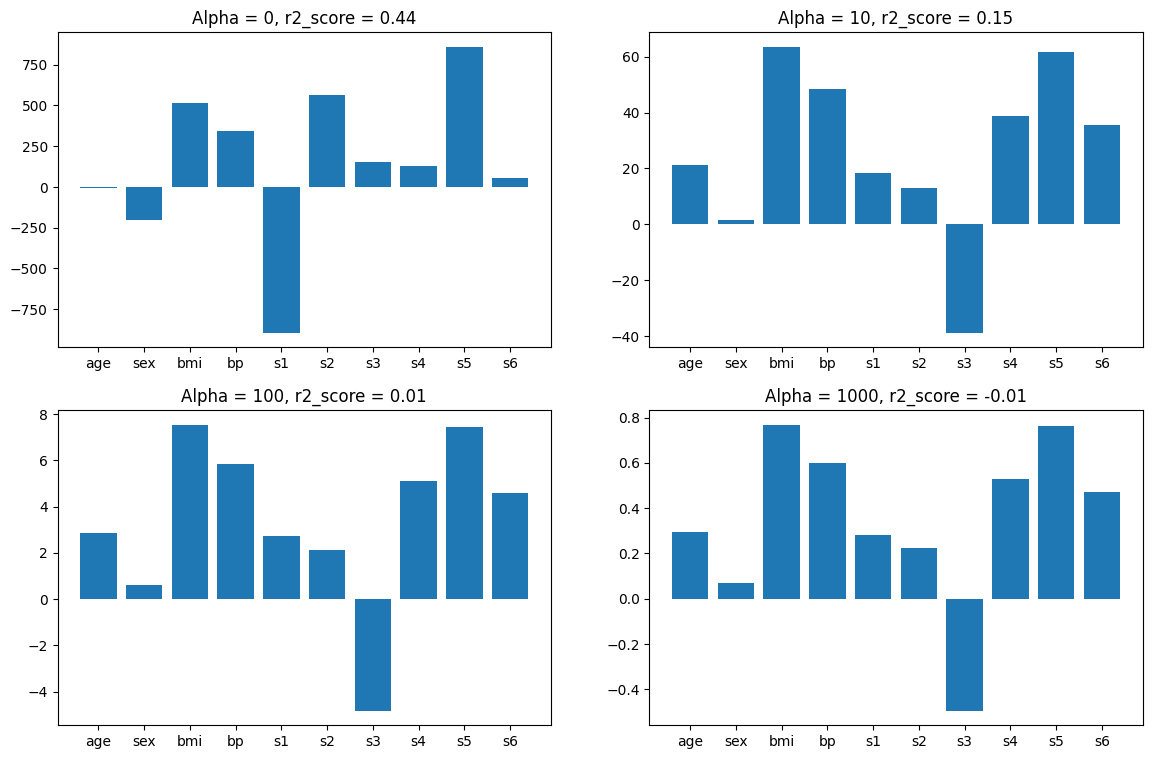

In [165]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0, r2_score = {}'.format(
    round(r2_scores[0],2)
))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10, r2_score = {}'.format(
    round(r2_scores[1],2)
))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100, r2_score = {}'.format(
    round(r2_scores[2],2)
))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000, r2_score = {}'.format(
    round(r2_scores[3],2)
))

plt.show()

we can see that
1. alpha=0, coef values are super high
2. alpha=10, coef values decreased
3. alpha=100, coef values decreased even more
4. alpha=1000, coef values almost reached 0, but never became 0.

**all coefficients shrink towards 0, but never becomes 0, upon increasing lambda from 0 to infinity**

*In Ridge regression coefficients never become 0*

y-axis : coefficients

# Higher Coefficients are affected more

**the higher the value of the coefficient the faster it shrinks compared to the rest of the coefficients, upon increasing lambda from 0 to infinity**

x-axis : lambda

black line -> coeff -> 0 line -> converge towards 0

In [166]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
  reg = Ridge(alpha=i)
  reg.fit(X_train,y_train)
  coefs.append(reg.coef_.tolist())


In [167]:
len(coefs)

10

In [168]:
len(coefs[0])

10

In [169]:
input_array = np.array(coefs)
input_array.shape

(10, 10)

In [170]:
coef_df = pd.DataFrame(
    input_array,columns=data.feature_names
)
coef_df['alpha'] = alphas
coef_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,alpha
0,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122,0.0000
1,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916,0.0001
2,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349,0.0010
3,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221,0.0100
4,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091,0.1000
5,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692,1.0000
6,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383,10.0000
7,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129,100.0000
8,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029,1000.0000
9,0.029674,0.006995,0.077054,0.059914,0.028412,0.022715,-0.049686,0.052870,0.076321,0.047241,10000.0000


In [171]:
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


the column having the higher coefficient(-ve or +ve) at alpha=0, shrinked way faster than the rest.

observe s1 : shrinked from -895.552002 to 0.028412

observe s5 : shrinked from 861.127002 to 0.076321

In [172]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
  reg = Ridge(alpha=i)
  reg.fit(X_train,y_train)

  coefs.append(reg.coef_.tolist())

*we will get y-axis column names as alphas from 0 to 10,
on x-axis, changes in coef value as alpha increases from 0 to 10*

In [173]:
input_array = np.array(coefs).T


In [174]:
input_array[0]

array([-9.15865318, -9.11611927, -8.95264833, -8.76148719, -7.54973811,
        6.64373321, 32.98691016, 42.24252786, 32.15601075, 21.17402443])

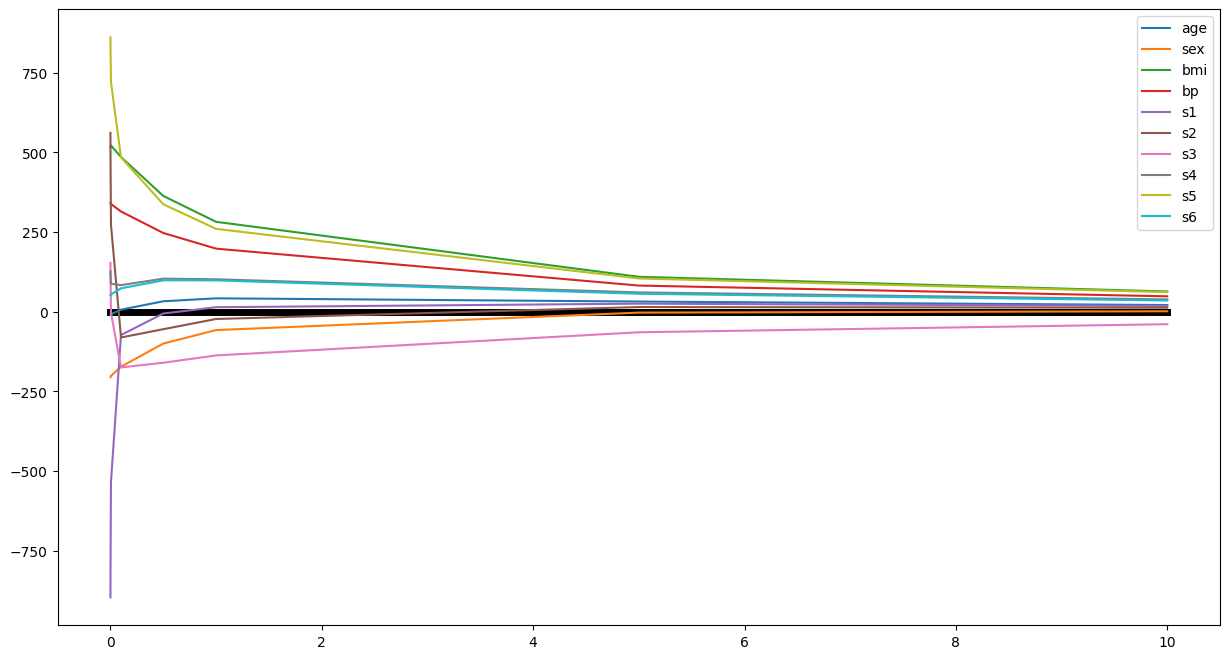

In [175]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',
         linewidth=5)
# iterate over all the feature names
for i in range(input_array.shape[0]):
  plt.plot(alphas,input_array[i],
           label=data.feature_names[i])
plt.legend()
plt.show()

*for a particular feature, we are gonna have 10 coef values as alpha ranges from 0 to 10*

*each row is for a single feature in the data*

black line -> coef = 0 line -> none of the coefficients become 0, but they converge towards 0

# Impact on bias and variance



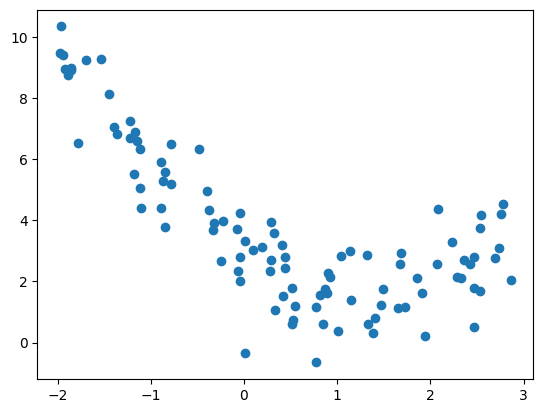

In [176]:
m = 100
X = 5 * np.random.rand(m,1) - 2
y = 0.7 * X ** 2 - 2*X + 3 + np.random.randn(m,1)

plt.scatter(X,y)
plt.show()

In [177]:
X_train,X_test,y_train,y_test = train_test_split(
    X.reshape(100,1), y.reshape(100), test_size=0.2, random_state=2
)

In [178]:
X_train.shape

(80, 1)

degree=15 applied on one input column -> X^0, X^1, X^2, X^3...X^15

therefore we get 16 columns

In [179]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

# extract polynomial features from input column
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [180]:
X_train.shape

(80, 16)

1. as lambda value decreases : bias decreases, variance increases, overfitting(on lowest value of lambda i.e close to 0)

2. as lambda value increases : bias increases, variance decreases, underfitting(on high value of lambda)

In [181]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test,
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

*Loss function is directly proportional to alpha*

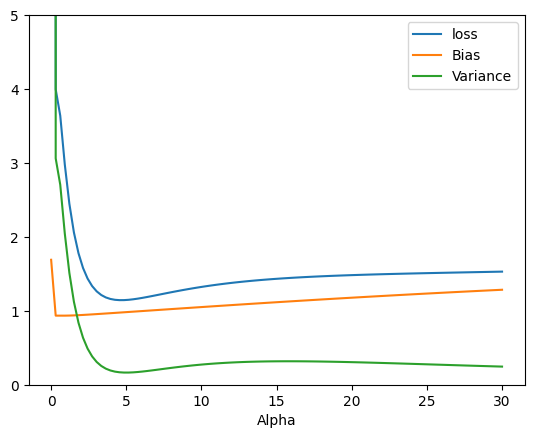

In [182]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,5)
plt.xlabel('Alpha')
plt.legend()


loss is generalisation error -> bias + variance

*intersection point is low bias,low variance point*

the best value of lambda -> is where bias is low and variance passes through that, so it is a value of lambda just before the intersection (where it is low bias, low variance) point

# Effect of Regularization on Loss Function

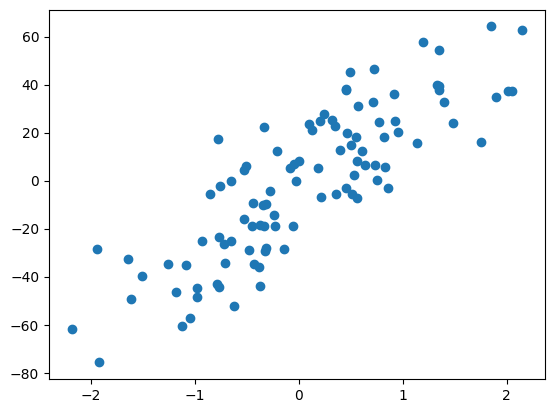

In [183]:
from sklearn.datasets import make_regression
X,y = make_regression(
    n_samples=100,n_features=1,n_informative=1,n_targets=1,
    noise=20,random_state=13

)
plt.scatter(X,y)


In [184]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


ridge loss ->
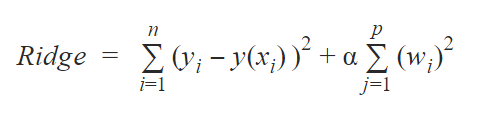

[27.82809103]
-2.29474455867698

In [194]:
def cal_loss(m,alpha):
  return np.sum((y - m*X.ravel() + 2.29)**2) + alpha * m*m


In [187]:
X.shape

(100, 1)

In [188]:
X.ravel().shape

(100,)

In [195]:
def predict(m):
  return m*X - 2.29

consider -> m to be varying, b to be constant

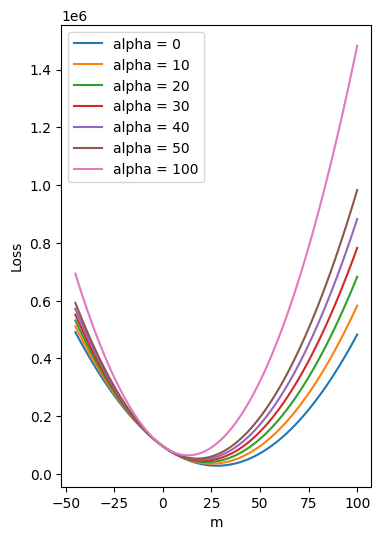

In [196]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
alphas = [0,10,20,30,40,50,100]
for j in alphas:
  loss = []
  for i in range(m.shape[0]):
    loss_i = cal_loss(m[i],j)
    loss.append(loss_i)
  plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('m')
plt.ylabel('Loss')
plt.show()


we can see that, as alpha value increases, m value shrinks, and the loss function shifts up and moves towards the origin.